In [1]:
from datascience import * 
import matplotlib
import numpy as np
import matplotlib.pyplot as plots
path_data = '../../data/data8/'
matplotlib.use('Agg')
%matplotlib inline
plots.style.use('fivethirtyeight')

In [2]:
goats = make_array("first goat", "second goat")

In [3]:
def other_goat(x):
    if x == "first goat":
        return "second goat"
    elif x == "second goat":
        return "first goat"

In [4]:
other_goat("first goat"), other_goat("second goat"), other_goat("Brainie")

('second goat', 'first goat', None)

In [5]:
hidden_behind_doors = np.append(goats, "car")
hidden_behind_doors

array(['first goat', 'second goat', 'car'],
      dtype='<U11')

We are now ready to simulate one play. To do this, we will define a function `monty_hall_game` that takes no arguments. When the function is called, it plays Monty’s game once and returns a list consisting of:

- the contestant’s guess

- what Monty reveals when he opens a door

- what remains behind the other door

The game starts with the contestant choosing one door at random. In doing so, the contestant makes a random choice from among the first goat, the second goat, and the car.

If the contestant happens to pick one of the goats, then the other goat is revealed and the car is behind the remaining door.

If the contestant happens to pick the car, then Monty reveals one of the goats and the other goat is behind the remaining door.

In [6]:
def monty_hall_game():
    """Return 
    [contestant's guess, what Monty reveals, what remains behind the other door]"""
    
    contestant_guess = np.random.choice(hidden_behind_doors)
    
    if contestant_guess == 'first goat':
        return [contestant_guess, 'second goat', 'car']
    
    if contestant_guess == 'second goat':
        return [contestant_guess, 'first goat', 'car']
    
    if contestant_guess == 'car':
        revealed = np.random.choice(goats)
        return [contestant_guess, revealed, other_goat(revealed)]

In [12]:
monty_hall_game()

['car', 'first goat', 'second goat']

Going to play the game 10000 times. Each time we return the guess, what is revealed and what is left.

Each one is appended to the row of the table.

In [13]:
# empty collection table
games = Table(['Guess', 'Revealed', 'Remaining'])

# Play the game 10000 times and 
# record the results in the table games

for i in np.arange(10000):
    games.append(monty_hall_game())

In [14]:
games.show(4)

Guess,Revealed,Remaining
car,second goat,first goat
second goat,first goat,car
car,first goat,second goat
car,second goat,first goat


In [15]:
original_choice = games.group("Guess")
original_choice

Guess,count
car,3457
first goat,3276
second goat,3267


In [16]:
remaining_door = games.group("Remaining")
remaining_door

Remaining,count
car,6543
first goat,1749
second goat,1708


In [18]:
joined = original_choice.join("Guess", remaining_door, "Remaining")
combined = joined.relabeled(0, "Item").relabeled(1, "Original Door").relabeled(2, "Remaining Door")
combined

Item,Original Door,Remaining Door
car,3457,6543
first goat,3276,1749
second goat,3267,1708


This shows you how often each item was behind the remaining door that was not opened by Monty. We see that the car was behind the unopened door almost 4 times as much.

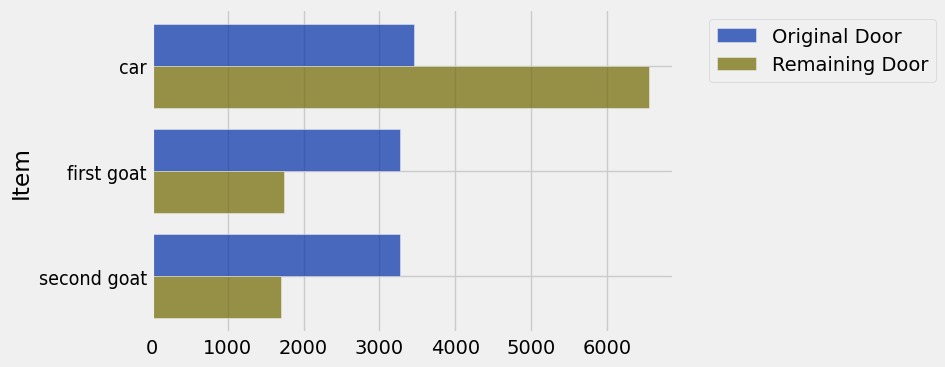

In [24]:
combined.barh(0)

Notice how the three blue bars are almost equal – the original choice is equally likely to be any of the three available items. But the gold bar corresponding to `Car` is twice as long as the blue.

The simulation confirms that the contestant is twice as likely to win if she switches.